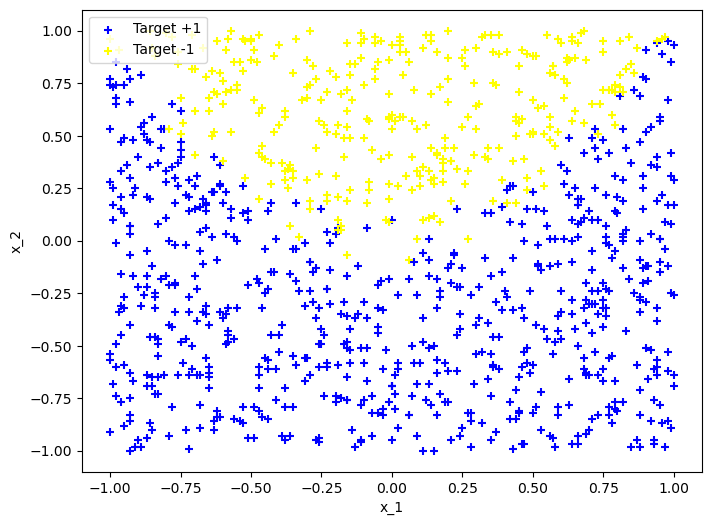

In [1]:
#On dataset header
# id:22-22--22 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("data.csv") 

X1 = df.iloc[:, 0] 
X2 = df.iloc[:, 1]
y = df.iloc[:, 2] 
X = np.column_stack((X1,X2))

plt.figure(figsize=(8, 6))
plt.scatter(X1[y == 1], X2[y == 1], marker='+', color='blue', label='Target +1')
plt.scatter(X1[y == -1], X2[y == -1], marker='+', color='yellow', label='Target -1')

plt.xlabel('x_1')
plt.ylabel('x_2')
plt.legend()
plt.show()

In [2]:
log_reg = LogisticRegression()
log_reg.fit(X, y)

coefficients = log_reg.coef_
intercept = log_reg.intercept_

print("Coefficients: ",coefficients)
print("Intercept: ", intercept)

coeff1 = abs(coefficients[0, 0])
coeff2 = abs(coefficients[0,1])

if coeff1 > coeff2:
    print("X1 has more influence")
else:
    print("X2 has more influence")

Coefficients:  [[-0.11826965 -4.93868508]]
Intercept:  [1.87247119]
X2 has more influence


Accuracy Score is 86.773547%


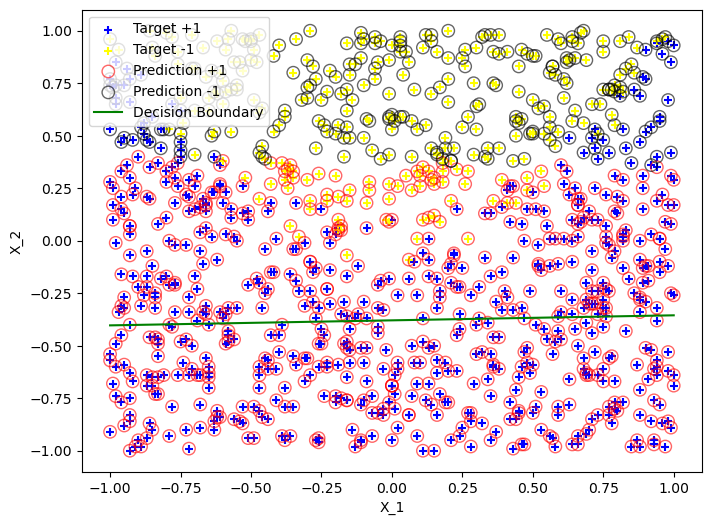

In [3]:
y_pred = log_reg.predict(X)

#Original Plot
plt.figure(figsize=(8, 6))
plt.scatter(X1[y == 1], X2[y == 1], marker='+', color='blue', label='Target +1')
plt.scatter(X1[y == -1], X2[y == -1], marker='+', color='yellow', label='Target -1')

#Plotting Predictions
plt.scatter(X1[y_pred == 1], X2[y_pred == 1], marker='o', edgecolor= 'red',facecolor='none',s=80,alpha=0.6, label ='Prediction +1')
plt.scatter(X1[y_pred == -1], X2[y_pred == -1], marker='o', edgecolor= 'black',facecolor='none',s=80,alpha=0.6, label ='Prediction -1')

x_values =np.linspace(min(X1), max(X1),100)
decision_boundary = (log_reg.intercept_  + log_reg.coef_[0][0]*x_values)/log_reg.coef_[0][1]

#plotting the boundary
plt.plot(x_values, decision_boundary,color='green',label = 'Decision Boundary')

plt.xlabel('X_1')
plt.ylabel('X_2')

plt.legend()

plt.show
accuracy = accuracy_score(y,y_pred)
accuracy *= 100

print(f"Accuracy Score is {accuracy:0f}%")

In [4]:
C_values = [0.001,1,100]

for C in C_values:
    print(f'Training C value: {C}')
    
    svm = LinearSVC(C=C, max_iter=10000)
    svm.fit(X,y)
    
    weights = svm.coef_[0]
    intercept = svm.intercept_
    
    print(f"C={C}:")
    print(f"Weights: {weights}")
    print(f"Intercept: {intercept}")

Training C value: 0.001
C=0.001:
Weights: [-0.00941439 -0.46250838]
Intercept: [0.24119188]
Training C value: 1
C=1:
Weights: [-0.03934495 -1.79252365]
Intercept: [0.66970409]
Training C value: 100
C=100:
Weights: [-0.03999341 -1.81184779]
Intercept: [0.67769767]


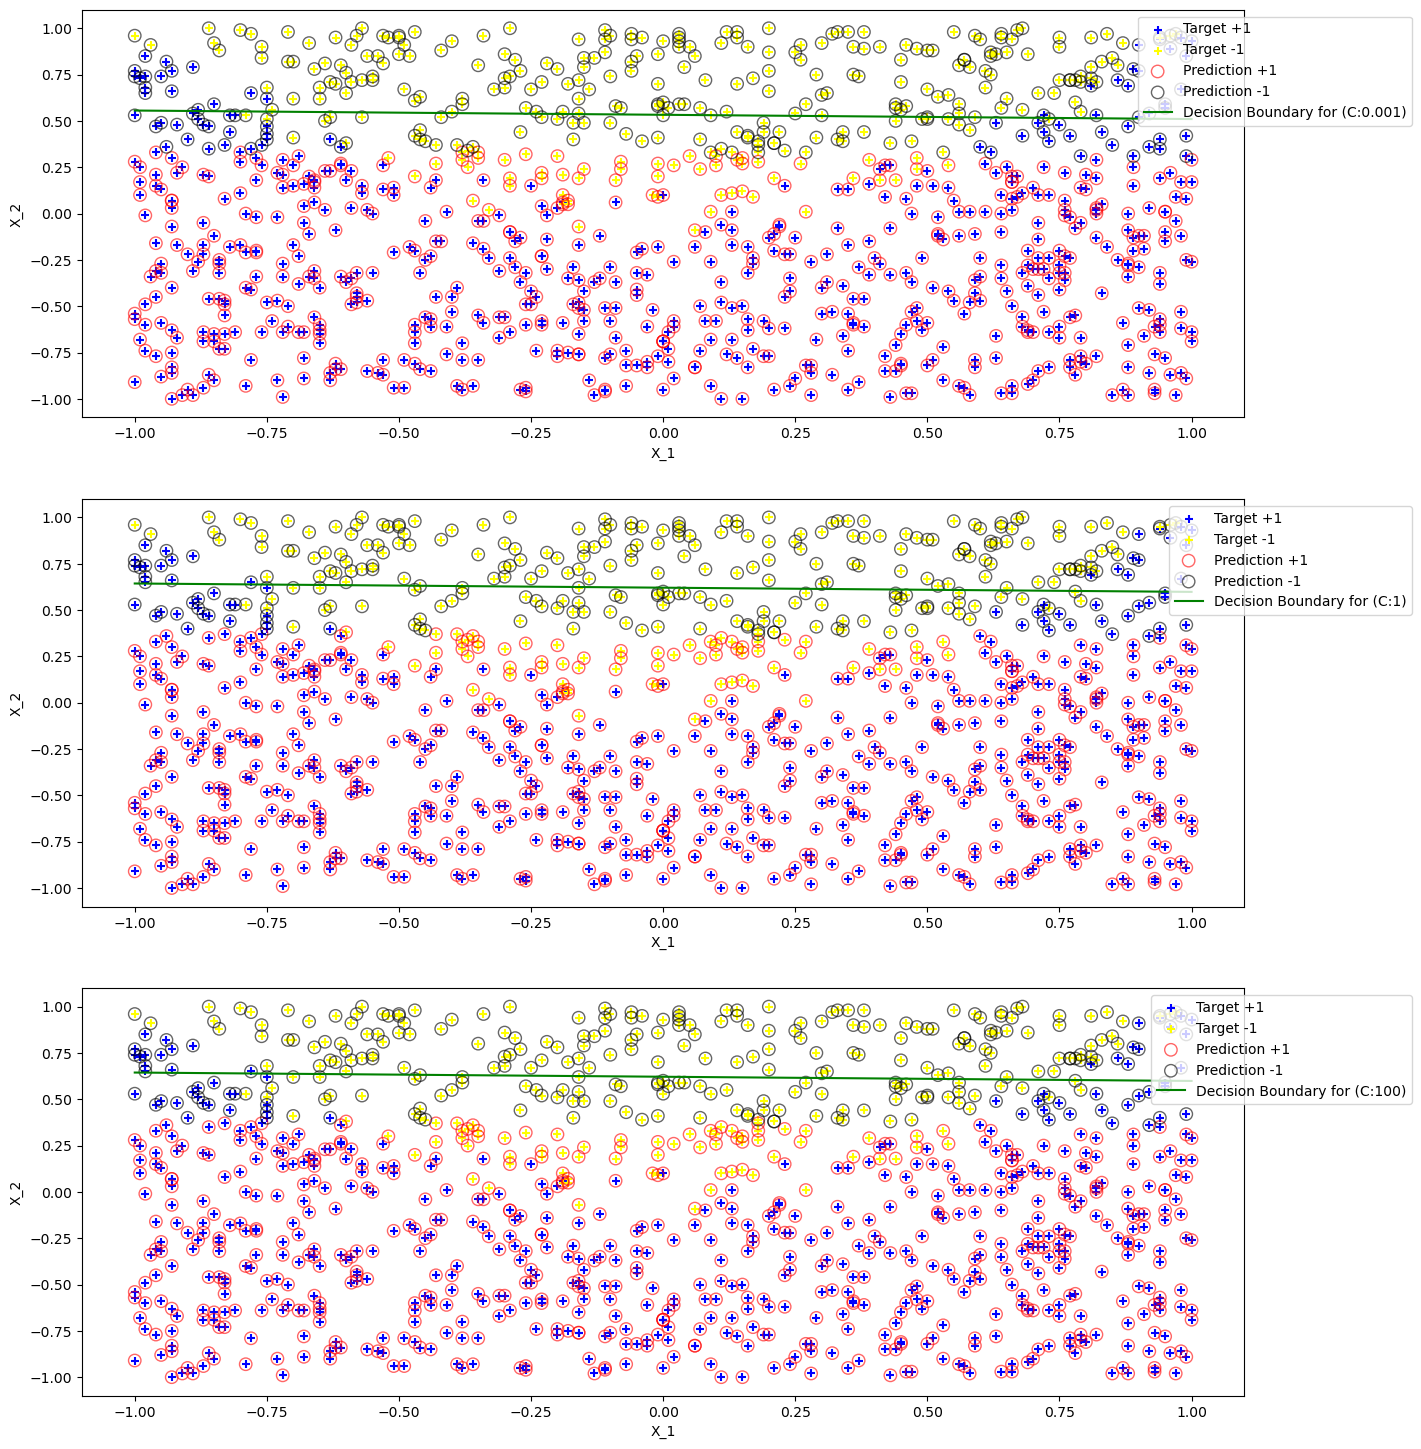

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(15,18))

for i,C in enumerate(C_values):
    svm = LinearSVC(C=C, max_iter =50000)
    svm.fit(X_scaled, y)
    
    y_pred = svm.predict(X_scaled)
    decision_boundary = -(svm.intercept_ + svm.coef_[0][0]*x_values) / svm.coef_[0][1]
    
    #Subplots for every C value
    plt.subplot(3,1,i+1)
    
    #Plotting actual values
    plt.scatter(X1[y == 1],X2[y == 1], marker='+', color='blue', label='Target +1')
    plt.scatter(X1[y == -1],X2[y == -1], marker='+',color='yellow', label= 'Target -1')
    
    #Plotting Predictions
    plt.scatter(X1[y_pred == 1],X2[y_pred == 1], marker='o', edgecolor='red',facecolor='none',s=80, alpha =0.6,label='Prediction +1')
    plt.scatter(X1[y_pred == -1],X2[y_pred == -1], marker='o', edgecolor='black',facecolor='none',s=80, alpha=0.6, label='Prediction -1')
    
    plt.plot(x_values, decision_boundary, color='green', label=f'Decision Boundary for (C:{C})')
    
    plt.xlabel('X_1')
    plt.ylabel('X_2')
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    
plt.show()
    

In [6]:
X1_squared = X1 ** 2
X2_squared = X2 ** 2

X_extended= np.column_stack((X1,X2,X1_squared,X2_squared))

log_reg_extended= LogisticRegression()
log_reg_extended.fit(X_extended, y)

coefficients = log_reg_extended.coef_
intercept = log_reg_extended.intercept_

print("Model Parameters:")
print(f"Weights: {coefficients}")
print(f"Intercept: {intercept}")



Model Parameters:
Weights: [[-0.01550065 -6.59730052  6.62372039 -0.99753732]]
Intercept: [0.35845795]


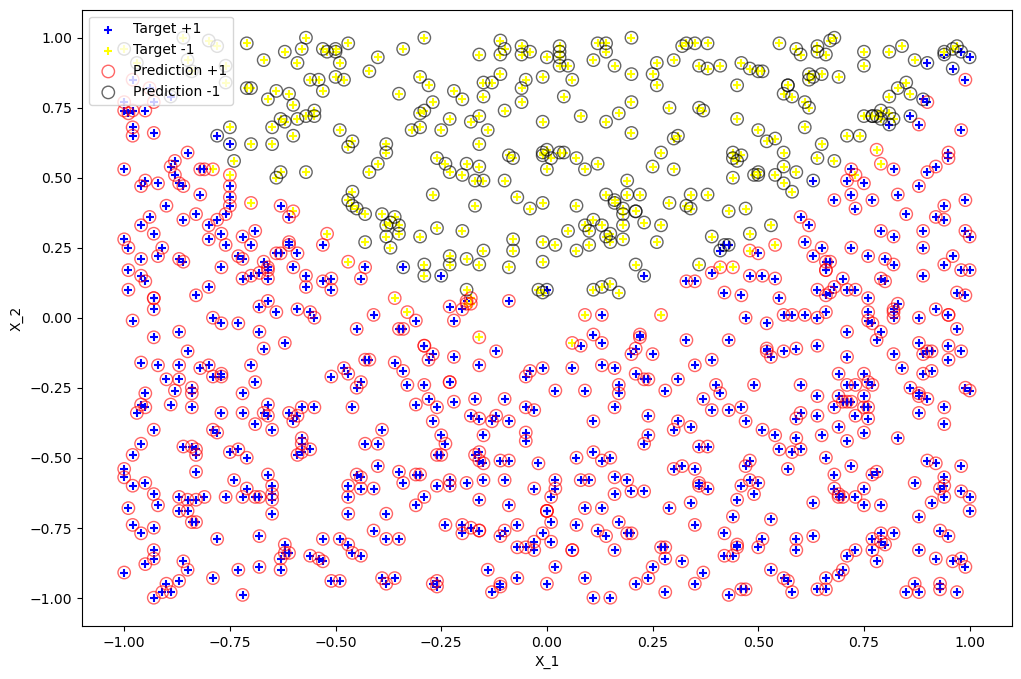

In [7]:
y_pred_extended = log_reg_extended.predict(X_extended)

plt.figure(figsize=(12,8))

#Plot actual values
plt.scatter(X1[y == 1],X2[y == 1], marker='+', color='blue', label='Target +1')
plt.scatter(X1[y == -1],X2[y == -1], marker='+',color='yellow', label= 'Target -1')
    
#Plot Predictions
plt.scatter(X1[y_pred_extended == 1],X2[y_pred_extended == 1], marker='o', edgecolor='red',facecolor='none',s=80, alpha =0.6,label='Prediction +1')
plt.scatter(X1[y_pred_extended == -1],X2[y_pred_extended == -1], marker='o', edgecolor='black',facecolor='none',s=80, alpha=0.6, label='Prediction -1')

plt.xlabel('X_1')
plt.ylabel('X_2')

plt.legend()

plt.show()

In [8]:
accuracy_log_reg = accuracy_score(y,y_pred_extended)

most_frequent_class = y.value_counts().idxmax()
y_pred_baseline = np.full_like(y,fill_value = most_frequent_class)

accuracy_baseline = accuracy_score(y, y_pred_baseline)
accuracy_log_reg *= 100
accuracy_baseline *= 100
print(f"Accuracy of Logistic Regression model: {accuracy_log_reg:.1f}%")
print(f"Accuracy of Baseline model (predicting all {most_frequent_class}): {accuracy_baseline:.1f}%")

Accuracy of Logistic Regression model: 95.9%
Accuracy of Baseline model (predicting all 1): 67.8%


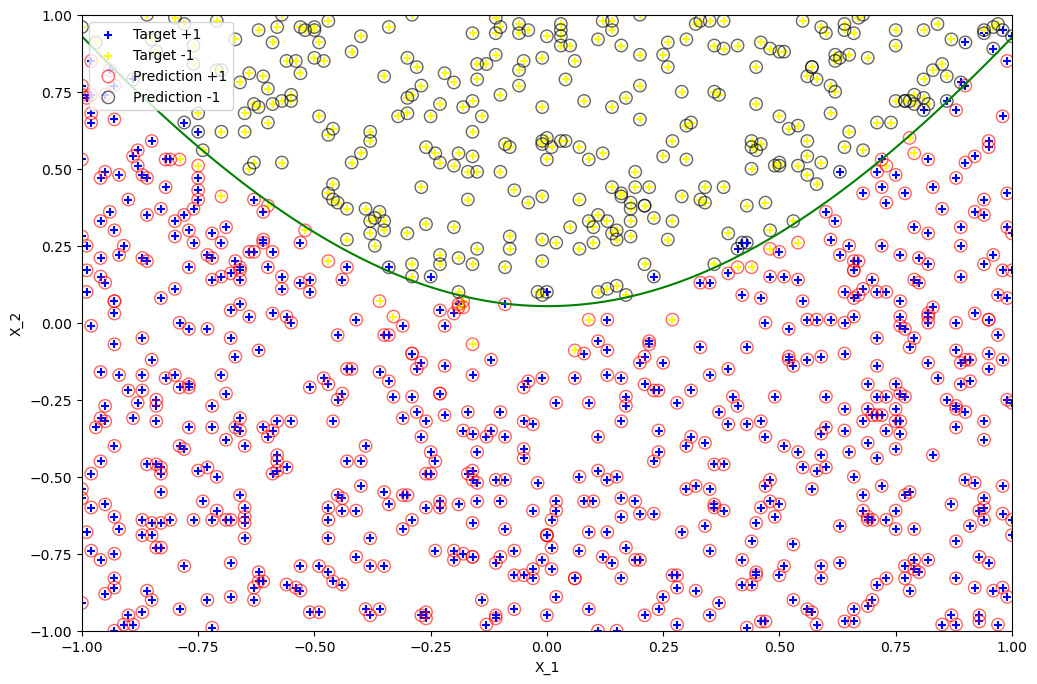

In [11]:
w0 = log_reg_extended.intercept_[0]
w1,w2,w3,w4 = log_reg_extended.coef_[0]

x1_values = np.linspace(X1.min(),X1.max(),500)
x2_values = np.linspace(X2.min(),X2.max(),500)
x1_grid, x2_grid = np.meshgrid(x1_values, x2_values)

decision_boundary= w0 + w1 * x1_grid + w2 * x2_grid + w3  * (x1_grid ** 2) + w4 * (x2_grid ** 2)

plt.figure(figsize=(12,8))

plt.scatter(X1[y == 1],X2[y == 1], marker='+', color='blue', label='Target +1')
plt.scatter(X1[y == -1],X2[y == -1], marker='+',color='yellow', label= 'Target -1')

plt.scatter(X1[y_pred_extended == 1],X2[y_pred_extended == 1], marker='o', edgecolor='red',facecolor='none',s=80, alpha =0.6,label='Prediction +1')
plt.scatter(X1[y_pred_extended == -1],X2[y_pred_extended == -1], marker='o', edgecolor='black',facecolor='none',s=80, alpha=0.6, label='Prediction -1')

plt.contour(x1_grid, x2_grid, decision_boundary, levels=[0], colors='green')

plt.xlabel('X_1')
plt.ylabel('X_2')

plt.legend()

plt.show()